# Diabetes Healthcare Analysis & Readmission Prediction

## Project Objective

## Dataset Overview

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/diabetic_data.csv")

df.shape

(101766, 50)

In [2]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

## Data Inspection

In [4]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Duplicate rows:", df.duplicated().sum())

Rows: 101766
Columns: 50
Duplicate rows: 0


In [5]:
df.isna().sum().sort_values(ascending=False).head(15)

max_glu_serum    96420
A1Cresult        84748
encounter_id         0
nateglinide          0
glimepiride          0
acetohexamide        0
glipizide            0
glyburide            0
tolbutamide          0
pioglitazone         0
rosiglitazone        0
acarbose             0
miglitol             0
troglitazone         0
tolazamide           0
dtype: int64

In [6]:
df["readmitted"].value_counts(dropna=False)

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [7]:
missing_marker_counts = (df == "?").sum().sort_values(ascending=False)

missing_marker_counts.head(20)

weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
encounter_id             0
tolazamide               0
glyburide                0
tolbutamide              0
pioglitazone             0
rosiglitazone            0
acarbose                 0
miglitol                 0
troglitazone             0
citoglipton              0
examide                  0
acetohexamide            0
insulin                  0
dtype: int64

In [8]:
missing_marker_percent = (
    (df == "?").mean() * 100
).sort_values(ascending=False)

missing_marker_percent.head(20)

weight               96.858479
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
encounter_id          0.000000
tolazamide            0.000000
glyburide             0.000000
tolbutamide           0.000000
pioglitazone          0.000000
rosiglitazone         0.000000
acarbose              0.000000
miglitol              0.000000
troglitazone          0.000000
citoglipton           0.000000
examide               0.000000
acetohexamide         0.000000
insulin               0.000000
dtype: float64

In [9]:
for column in ["weight", "payer_code", "medical_specialty", "race", "gender"]:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False).head(10))


weight
weight
?            98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64

payer_code
payer_code
?     40256
MC    32439
HM     6274
SP     5007
BC     4655
MD     3532
CP     2533
UN     2448
CM     1937
OG     1033
Name: count, dtype: int64

medical_specialty
medical_specialty
?                             49949
InternalMedicine              14635
Emergency/Trauma               7565
Family/GeneralPractice         7440
Cardiology                     5352
Surgery-General                3099
Nephrology                     1613
Orthopedics                    1400
Orthopedics-Reconstructive     1233
Radiologist                    1140
Name: count, dtype: int64

race
race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dty

In [10]:
id_columns = ["encounter_id", "patient_nbr"]

for column in id_columns:
    print(f"\n{column}")
    print("Unique values:", df[column].nunique())
    print("Duplicate values:", df[column].duplicated().sum())


encounter_id
Unique values: 101766
Duplicate values: 0

patient_nbr
Unique values: 71518
Duplicate values: 30248


In [11]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False).head(10))


--- race ---
race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

--- gender ---
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64

--- age ---
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

--- weight ---
weight
?            98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64

--- payer_code ---
payer_code
?     40256
MC    32439
HM     6274
SP     5007
BC     4655
MD     3532
CP     2533
UN     2448
CM     1937
OG     1033
Name: count, dtype: int64

--- medical_specialty ---
medical_special

## Data Cleaning

In [12]:
import numpy as np

df_clean = df.copy()

# Preserve patient identifier for later patient-level splitting.
# It will not be used as a model feature.

# Convert dataset-specific missing markers to NaN
missing_marker_columns = [
    "race",
    "weight",
    "payer_code",
    "medical_specialty",
    "diag_1",
    "diag_2",
    "diag_3"
]

df_clean[missing_marker_columns] = (
    df_clean[missing_marker_columns]
    .replace("?", np.nan)
)

df_clean.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [13]:
# Remove variables with extremely high missingness
df_clean = df_clean.drop(columns=["weight"])

# Remove constant variables
constant_columns = [
    column
    for column in df_clean.columns
    if df_clean[column].nunique(dropna=False) <= 1
]

constant_columns

['examide', 'citoglipton']

In [14]:
df_clean = df_clean.drop(columns=constant_columns)

print("Removed constant columns:", constant_columns)
print("New shape:", df_clean.shape)

Removed constant columns: ['examide', 'citoglipton']
New shape: (101766, 47)


In [15]:
categorical_missing_columns = [
    "race",
    "payer_code",
    "medical_specialty",
    "diag_1",
    "diag_2",
    "diag_3"
]

df_clean[categorical_missing_columns] = (
    df_clean[categorical_missing_columns]
    .fillna("Unknown")
)

In [16]:
df_clean[categorical_missing_columns].isna().sum()

race                 0
payer_code           0
medical_specialty    0
diag_1               0
diag_2               0
diag_3               0
dtype: int64

In [17]:
age_mapping = {
    "[0-10)": 5,
    "[10-20)": 15,
    "[20-30)": 25,
    "[30-40)": 35,
    "[40-50)": 45,
    "[50-60)": 55,
    "[60-70)": 65,
    "[70-80)": 75,
    "[80-90)": 85,
    "[90-100)": 95
}

df_clean["age_numeric"] = df_clean["age"].map(age_mapping)

In [18]:
df_clean[["age", "age_numeric"]].drop_duplicates().sort_values("age_numeric")

,age,age_numeric
0,[0-10),5
1,[10-20),15
2,[20-30),25
3,[30-40),35
4,[40-50),45
5,[50-60),55
6,[60-70),65
7,[70-80),75
8,[80-90),85
9,[90-100),95


In [19]:
df_clean["readmission_30d"] = (
    df_clean["readmitted"] == "<30"
).astype(int)

df_clean["readmission_30d"].value_counts()

readmission_30d
0    90409
1    11357
Name: count, dtype: int64

In [20]:
pd.crosstab(
    df_clean["readmitted"],
    df_clean["readmission_30d"]
)

readmission_30d,0,1
readmitted,,
<30,0,11357
>30,35545,0
NO,54864,0


In [21]:
for column in ["diag_1", "diag_2", "diag_3"]:
    print(
        column,
        "unique codes:",
        df_clean[column].nunique()
    )

diag_1 unique codes: 717
diag_2 unique codes: 749
diag_3 unique codes: 790


In [22]:
df_clean[["diag_1", "diag_2", "diag_3"]].head(10)

,diag_1,diag_2,diag_3
0,250.83,Unknown,Unknown
1,276,250.01,255
2,648,250,V27
3,8,250.43,403
4,197,157,250
5,414,411,250
6,414,411,V45
7,428,492,250
8,398,427,38
9,434,198,486


In [23]:
def get_icd9_category(code):
    if pd.isna(code) or code == "Unknown":
        return "Unknown"
    
    code = str(code)
    
    if code.startswith("V"):
        return "V-code"
    elif code.startswith("E"):
        return "E-code"
    
    try:
        numeric_code = float(code)
        
        if 390 <= numeric_code < 460:
            return "Circulatory"
        elif 460 <= numeric_code < 520:
            return "Respiratory"
        elif 520 <= numeric_code < 580:
            return "Digestive"
        elif 580 <= numeric_code < 630:
            return "Genitourinary"
        elif 630 <= numeric_code < 680:
            return "Pregnancy"
        elif 680 <= numeric_code < 710:
            return "Skin"
        elif 710 <= numeric_code < 740:
            return "Musculoskeletal"
        elif 740 <= numeric_code < 760:
            return "Congenital"
        elif 760 <= numeric_code < 780:
            return "Perinatal"
        elif 780 <= numeric_code < 800:
            return "Symptoms"
        elif 800 <= numeric_code < 1000:
            return "Injury"
        elif 250 <= numeric_code < 251:
            return "Diabetes"
        else:
            return "Other"
            
    except ValueError:
        return "Other"

In [24]:
for column in ["diag_1", "diag_2", "diag_3"]:
    df_clean[f"{column}_category"] = df_clean[column].apply(get_icd9_category)

In [25]:
for column in ["diag_1_category", "diag_2_category", "diag_3_category"]:
    print(f"\n--- {column} ---")
    print(df_clean[column].value_counts())


--- diag_1_category ---
diag_1_category
Circulatory        30336
Other              13479
Respiratory        10407
Digestive           9208
Diabetes            8757
Symptoms            7636
Injury              6974
Genitourinary       5078
Musculoskeletal     4957
Skin                2530
V-code              1644
Pregnancy            687
Congenital            51
Unknown               21
E-code                 1
Name: count, dtype: int64

--- diag_2_category ---
diag_2_category
Circulatory        31365
Other              19570
Diabetes           12794
Respiratory        10251
Genitourinary       7987
Symptoms            4632
Digestive           3962
Skin                3596
Injury              2428
V-code              1805
Musculoskeletal     1764
E-code               731
Pregnancy            415
Unknown              358
Congenital           108
Name: count, dtype: int64

--- diag_3_category ---
diag_3_category
Circulatory        29918
Other              20260
Diabetes           17157


In [26]:
df_clean.shape

(101766, 52)

In [27]:
df_clean.isna().sum().sort_values(ascending=False).head(15)

max_glu_serum          96420
A1Cresult              84748
encounter_id               0
insulin                    0
glipizide                  0
glyburide                  0
tolbutamide                0
pioglitazone               0
rosiglitazone              0
acarbose                   0
miglitol                   0
troglitazone               0
tolazamide                 0
glyburide-metformin        0
glimepiride                0
dtype: int64

In [28]:
df_clean.to_csv(
    "../data/cleaned/diabetes_cleaned_intermediate.csv",
    index=False
)

print("Saved:", df_clean.shape)

Saved: (101766, 52)


## Exploratory Analysis

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_analysis = pd.read_csv(
    "../data/cleaned/diabetes_cleaned_intermediate.csv"
)

print("Shape:", df_analysis.shape)
df_analysis.head()

Shape: (101766, 52)


,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,...,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,age_numeric,readmission_30d,diag_1_category,diag_2_category,diag_3_category
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,Unknown,...,No,No,No,No,NO,5,0,Diabetes,Unknown,Unknown
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,Unknown,...,No,No,Ch,Yes,>30,15,0,Other,Diabetes,Other
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,...,No,No,No,Yes,NO,25,0,Pregnancy,Diabetes,V-code
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,Unknown,...,No,No,Ch,Yes,NO,35,0,Other,Diabetes,Circulatory
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,Unknown,...,No,No,Ch,Yes,NO,45,0,Other,Other,Diabetes


In [30]:
readmission_counts = df_analysis["readmission_30d"].value_counts()
readmission_rates = df_analysis["readmission_30d"].value_counts(normalize=True) * 100

print("Readmission counts:")
print(readmission_counts)

print("\nReadmission rates:")
print(readmission_rates.round(2))

Readmission counts:
readmission_30d
0    90409
1    11357
Name: count, dtype: int64

Readmission rates:
readmission_30d
0    88.84
1    11.16
Name: proportion, dtype: float64


In [31]:
readmission_summary = pd.DataFrame({
    "count": readmission_counts,
    "percentage": readmission_rates.round(2)
})

readmission_summary

,count,percentage
readmission_30d,,
0,90409,88.84
1,11357,11.16


In [32]:
age_summary = (
    df_analysis
    .groupby("readmission_30d")["age_numeric"]
    .agg(["count", "mean", "median", "std"])
)

age_summary

,count,mean,median,std
readmission_30d,,,,
0,90409,65.867392,65.0,15.957612
1,11357,66.760148,65.0,15.784953


<Figure size 800x500 with 0 Axes>

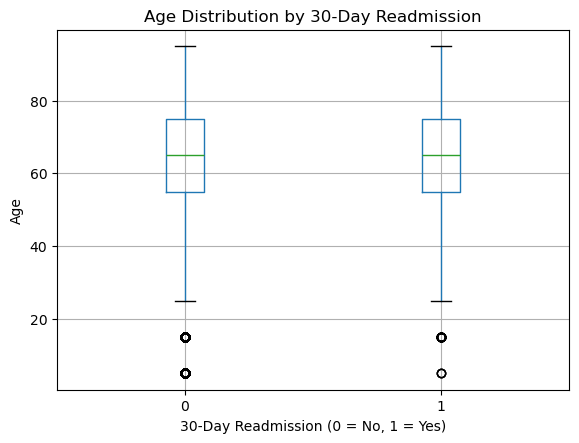

In [33]:
plt.figure(figsize=(8, 5))

df_analysis.boxplot(
    column="age_numeric",
    by="readmission_30d"
)

plt.title("Age Distribution by 30-Day Readmission")
plt.suptitle("")
plt.xlabel("30-Day Readmission (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()

In [34]:
utilisation_summary = (
    df_analysis
    .groupby("readmission_30d")[
        ["number_inpatient", "number_emergency", "number_outpatient"]
    ]
    .agg(["mean", "median", "std"])
)

utilisation_summary

number_inpatient                  number_emergency         \
                            mean median       std             mean median   
readmission_30d                                                             
0                       0.561648    0.0  1.125315         0.177803    0.0   
1                       1.224003    0.0  1.954577         0.357313    0.0   

                          number_outpatient                   
                      std              mean median       std  
readmission_30d                                               
0                0.857353          0.360871    0.0  1.262484  
1                1.370384          0.436911    0.0  1.302788

In [35]:
utilisation_means = (
    df_analysis
    .groupby("readmission_30d")[
        ["number_inpatient", "number_emergency", "number_outpatient"]
    ]
    .mean()
    .round(2)
)

utilisation_means

,number_inpatient,number_emergency,number_outpatient
readmission_30d,,,
0,0.56,0.18,0.36
1,1.22,0.36,0.44


In [36]:
los_summary = (
    df_analysis
    .groupby("readmission_30d")["time_in_hospital"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

los_summary

,count,mean,median,std,min,max
readmission_30d,,,,,,
0,90409,4.349224,4.0,2.976382,1,14
1,11357,4.768249,4.0,3.028165,1,14


<Figure size 800x500 with 0 Axes>

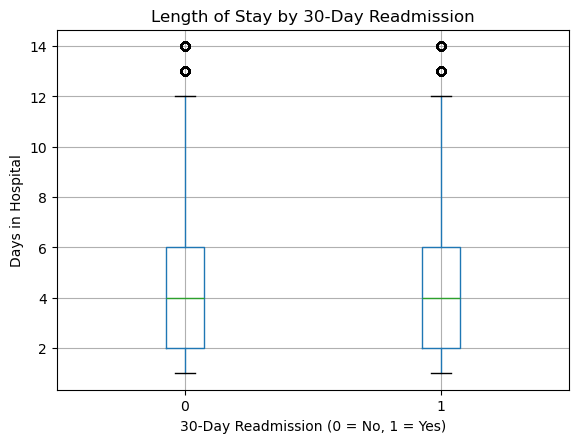

In [37]:
plt.figure(figsize=(8, 5))

df_analysis.boxplot(
    column="time_in_hospital",
    by="readmission_30d"
)

plt.title("Length of Stay by 30-Day Readmission")
plt.suptitle("")
plt.xlabel("30-Day Readmission (0 = No, 1 = Yes)")
plt.ylabel("Days in Hospital")
plt.show()

### Statistical Comparison of Continuous Variables

In [38]:
from scipy.stats import ttest_ind

continuous_variables = [
    "age_numeric",
    "time_in_hospital",
    "number_inpatient",
    "number_emergency",
    "number_outpatient"
]

statistical_results = []

for variable in continuous_variables:
    no_readmission = df_analysis.loc[
        df_analysis["readmission_30d"] == 0,
        variable
    ].dropna()
    
    readmission = df_analysis.loc[
        df_analysis["readmission_30d"] == 1,
        variable
    ].dropna()
    
    t_stat, p_value = ttest_ind(
        no_readmission,
        readmission,
        equal_var=False
    )
    
    statistical_results.append({
        "variable": variable,
        "mean_no_readmission": no_readmission.mean(),
        "mean_readmission": readmission.mean(),
        "mean_difference": readmission.mean() - no_readmission.mean(),
        "t_statistic": t_stat,
        "p_value": p_value
    })

statistical_results = pd.DataFrame(statistical_results)

statistical_results

,variable,mean_no_readmission,mean_readmission,mean_difference,t_statistic,p_value
0,age_numeric,65.867392,66.760148,0.892756,-5.674056,1.421353e-08
1,time_in_hospital,4.349224,4.768249,0.419025,-13.925782,8.549547e-44
2,number_inpatient,0.561648,1.224003,0.662355,-35.384370,2.756356e-261
3,number_emergency,0.177803,0.357313,0.179510,-13.628704,5.394092e-42
4,number_outpatient,0.360871,0.436911,0.076040,-5.882825,4.124195e-09


In [39]:
def cohens_d(group1, group2):
    n1 = len(group1)
    n2 = len(group2)
    
    var1 = group1.var(ddof=1)
    var2 = group2.var(ddof=1)
    
    pooled_sd = np.sqrt(
        ((n1 - 1) * var1 + (n2 - 1) * var2)
        / (n1 + n2 - 2)
    )
    
    return (group2.mean() - group1.mean()) / pooled_sd


effect_sizes = []

for variable in continuous_variables:
    no_readmission = df_analysis.loc[
        df_analysis["readmission_30d"] == 0,
        variable
    ].dropna()
    
    readmission = df_analysis.loc[
        df_analysis["readmission_30d"] == 1,
        variable
    ].dropna()
    
    effect_sizes.append({
        "variable": variable,
        "cohens_d": cohens_d(no_readmission, readmission)
    })

effect_sizes = pd.DataFrame(effect_sizes)

effect_sizes

,variable,cohens_d
0,age_numeric,0.056013
1,time_in_hospital,0.140508
2,number_inpatient,0.531786
3,number_emergency,0.193279
4,number_outpatient,0.060014


### Categorical Variables and 30-Day Readmission

In [40]:
categorical_variables = [
    "gender",
    "race",
    "age",
    "diabetesMed",
    "change"
]

categorical_summaries = {}

for variable in categorical_variables:
    summary = (
        pd.crosstab(
            df_analysis[variable],
            df_analysis["readmission_30d"],
            normalize="index"
        ) * 100
    )
    
    summary.columns = [
        "No readmission (%)",
        "30-day readmission (%)"
    ]
    
    categorical_summaries[variable] = summary.round(2)

categorical_summaries["gender"]

,No readmission (%),30-day readmission (%)
gender,,
Female,88.75,11.25
Male,88.94,11.06
Unknown/Invalid,100.00,0.00


In [41]:
categorical_summaries["race"]

,No readmission (%),30-day readmission (%)
race,,
AfricanAmerican,88.78,11.22
Asian,89.86,10.14
Caucasian,88.71,11.29
Hispanic,89.59,10.41
Other,90.37,9.63
Unknown,91.73,8.27


In [42]:
categorical_summaries["age"]

,No readmission (%),30-day readmission (%)
age,,
[0-10),98.14,1.86
[10-20),94.21,5.79
[20-30),85.76,14.24
[30-40),88.77,11.23
[40-50),89.40,10.60
[50-60),90.33,9.67
[60-70),88.87,11.13
[70-80),88.23,11.77
[80-90),87.92,12.08


In [43]:
categorical_summaries["diabetesMed"]

,No readmission (%),30-day readmission (%)
diabetesMed,,
No,90.40,9.60
Yes,88.37,11.63


In [44]:
categorical_summaries["change"]

,No readmission (%),30-day readmission (%)
change,,
Ch,88.18,11.82
No,89.41,10.59


In [45]:
from scipy.stats import chi2_contingency

chi_square_results = []

for variable in categorical_variables:
    contingency_table = pd.crosstab(
        df_analysis[variable],
        df_analysis["readmission_30d"]
    )
    
    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )
    
    chi_square_results.append({
        "variable": variable,
        "chi2": chi2,
        "degrees_of_freedom": dof,
        "p_value": p_value
    })

chi_square_results = pd.DataFrame(chi_square_results)

chi_square_results

,variable,chi2,degrees_of_freedom,p_value
0,gender,1.237255,2,5.386833e-01
1,race,25.908488,5,9.295748e-05
2,age,116.608911,9,6.597923e-21
3,diabetesMed,74.669432,1,5.565116e-18
4,change,38.596055,1,5.212417e-10


In [46]:
def cramers_v(contingency_table):
    chi2, _, _, _ = chi2_contingency(contingency_table)
    
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape
    
    phi2 = chi2 / n
    
    phi2_corrected = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )
    
    r_corrected = r - ((r - 1) ** 2) / (n - 1)
    k_corrected = k - ((k - 1) ** 2) / (n - 1)
    
    denominator = min(
        k_corrected - 1,
        r_corrected - 1
    )
    
    return np.sqrt(phi2_corrected / denominator)


cramers_results = []

for variable in categorical_variables:
    contingency_table = pd.crosstab(
        df_analysis[variable],
        df_analysis["readmission_30d"]
    )
    
    cramers_results.append({
        "variable": variable,
        "cramers_v": cramers_v(contingency_table)
    })

cramers_results = pd.DataFrame(cramers_results)

cramers_results

,variable,cramers_v
0,gender,0.000000
1,race,0.014334
2,age,0.032518
3,diabetesMed,0.026906
4,change,0.019221


### Clinical and Encounter Characteristics

In [47]:
clinical_variables = [
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_diagnoses"
]

clinical_summary = (
    df_analysis
    .groupby("readmission_30d")[clinical_variables]
    .agg(["mean", "median", "std"])
)

clinical_summary.round(2)

num_lab_procedures               num_procedures               \
                              mean median    std           mean median   std   
readmission_30d                                                                
0                            42.95   44.0  19.72           1.35    1.0  1.71   
1                            44.23   45.0  19.28           1.28    1.0  1.64   

                num_medications              number_diagnoses               
                           mean median   std             mean median   std  
readmission_30d                                                             
0                         15.91   15.0  8.12             7.39    8.0  1.95  
1                         16.90   16.0  8.10             7.69    9.0  1.77

In [48]:
clinical_results = []

for variable in clinical_variables:
    no_readmission = df_analysis.loc[
        df_analysis["readmission_30d"] == 0,
        variable
    ].dropna()
    
    readmission = df_analysis.loc[
        df_analysis["readmission_30d"] == 1,
        variable
    ].dropna()
    
    t_stat, p_value = ttest_ind(
        no_readmission,
        readmission,
        equal_var=False
    )
    
    d = cohens_d(no_readmission, readmission)
    
    clinical_results.append({
        "variable": variable,
        "mean_no_readmission": no_readmission.mean(),
        "mean_readmission": readmission.mean(),
        "mean_difference": readmission.mean() - no_readmission.mean(),
        "t_statistic": t_stat,
        "p_value": p_value,
        "cohens_d": d
    })

clinical_results = pd.DataFrame(clinical_results)

clinical_results.round(4)

,variable,mean_no_readmission,mean_readmission,mean_difference,t_statistic,p_value,cohens_d
0,num_lab_procedures,42.9536,44.2260,1.2724,-6.6132,0.0000,0.0647
1,num_procedures,1.3471,1.2809,-0.0662,4.0449,0.0001,-0.0388
2,num_medications,15.9111,16.9031,0.9920,-12.3020,0.0000,0.1221
3,number_diagnoses,7.3887,7.6928,0.3041,-17.0274,0.0000,0.1575


In [49]:
for variable in ["max_glu_serum", "A1Cresult"]:
    print(f"\n{variable}")
    
    summary = (
        pd.crosstab(
            df_analysis[variable],
            df_analysis["readmission_30d"],
            normalize="index"
        ) * 100
    )
    
    summary.columns = [
        "No readmission (%)",
        "30-day readmission (%)"
    ]
    
    print(summary.round(2))


max_glu_serum
               No readmission (%)  30-day readmission (%)
max_glu_serum                                            
>200                        87.54                   12.46
>300                        85.68                   14.32
Norm                        88.64                   11.36

A1Cresult
           No readmission (%)  30-day readmission (%)
A1Cresult                                            
>7                      89.95                   10.05
>8                      90.13                    9.87
Norm                    90.34                    9.66


In [50]:
measurement_variables = ["max_glu_serum", "A1Cresult"]

for variable in measurement_variables:
    measurement_status = df_analysis[variable].fillna("Not measured")
    
    summary = (
        pd.crosstab(
            measurement_status,
            df_analysis["readmission_30d"],
            normalize="index"
        ) * 100
    )
    
    summary.columns = [
        "No readmission (%)",
        "30-day readmission (%)"
    ]
    
    print(f"\n{variable}")
    display(summary.round(2))


max_glu_serum


,No readmission (%),30-day readmission (%)
max_glu_serum,,
>200,87.54,12.46
>300,85.68,14.32
Norm,88.64,11.36
Not measured,88.91,11.09



A1Cresult


,No readmission (%),30-day readmission (%)
A1Cresult,,
>7,89.95,10.05
>8,90.13,9.87
Norm,90.34,9.66
Not measured,88.58,11.42


In [51]:
primary_diagnosis_summary = (
    pd.crosstab(
        df_analysis["diag_1_category"],
        df_analysis["readmission_30d"],
        normalize="index"
    ) * 100
)

primary_diagnosis_summary.columns = [
    "No readmission (%)",
    "30-day readmission (%)"
]

primary_diagnosis_summary = (
    primary_diagnosis_summary
    .sort_values("30-day readmission (%)", ascending=False)
)

primary_diagnosis_summary.round(2)

,No readmission (%),30-day readmission (%)
diag_1_category,,
Unknown,76.19,23.81
V-code,83.82,16.18
Diabetes,87.02,12.98
Injury,87.75,12.25
Circulatory,88.55,11.45
Other,88.57,11.43
Genitourinary,89.19,10.81
Respiratory,89.31,10.69
Digestive,89.51,10.49


In [52]:
primary_diagnosis_counts = (
    df_analysis["diag_1_category"]
    .value_counts()
    .rename("encounters")
)

primary_diagnosis_readmissions = (
    df_analysis
    .groupby("diag_1_category")["readmission_30d"]
    .agg(["sum", "mean"])
    .rename(columns={
        "sum": "readmissions",
        "mean": "readmission_rate"
    })
)

primary_diagnosis_analysis = (
    primary_diagnosis_counts
    .to_frame()
    .join(primary_diagnosis_readmissions)
)

primary_diagnosis_analysis["readmission_rate"] *= 100

primary_diagnosis_analysis = (
    primary_diagnosis_analysis
    .sort_values("readmission_rate", ascending=False)
)

primary_diagnosis_analysis.round(2)

,encounters,readmissions,readmission_rate
diag_1_category,,,
Unknown,21,5,23.81
V-code,1644,266,16.18
Diabetes,8757,1137,12.98
Injury,6974,854,12.25
Circulatory,30336,3474,11.45
Other,13479,1540,11.43
Genitourinary,5078,549,10.81
Respiratory,10407,1112,10.69
Digestive,9208,966,10.49


In [53]:
diagnosis_contingency = pd.crosstab(
    df_analysis["diag_1_category"],
    df_analysis["readmission_30d"]
)

chi2, p_value, dof, expected = chi2_contingency(
    diagnosis_contingency
)

diagnosis_cramers_v = cramers_v(diagnosis_contingency)

print("Chi-square statistic:", round(chi2, 3))
print("Degrees of freedom:", dof)
print("p-value:", p_value)
print("Cramér's V:", round(diagnosis_cramers_v, 4))

Chi-square statistic: 165.853
Degrees of freedom: 14
p-value: 4.704793799761486e-28
Cramér's V: 0.0386


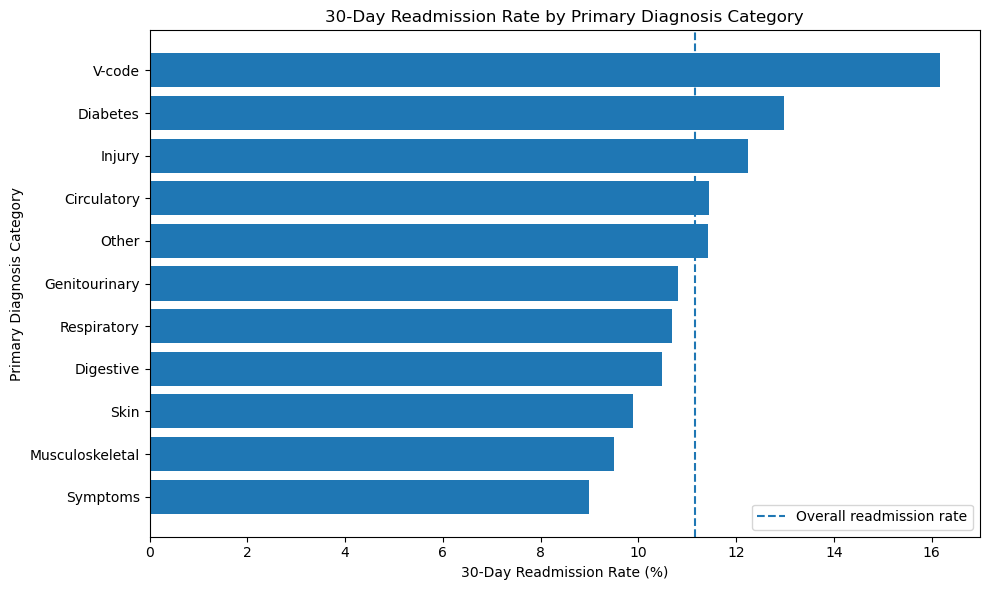

In [54]:
diagnosis_plot = (
    primary_diagnosis_analysis[
        primary_diagnosis_analysis["encounters"] >= 1000
    ]
    .sort_values("readmission_rate")
)

plt.figure(figsize=(10, 6))

plt.barh(
    diagnosis_plot.index,
    diagnosis_plot["readmission_rate"]
)

plt.xlabel("30-Day Readmission Rate (%)")
plt.ylabel("Primary Diagnosis Category")
plt.title("30-Day Readmission Rate by Primary Diagnosis Category")

plt.axvline(
    df_analysis["readmission_30d"].mean() * 100,
    linestyle="--",
    label="Overall readmission rate"
)

plt.legend()
plt.tight_layout()
plt.show()

In [55]:
statistical_results.to_csv(
    "../data/cleaned/continuous_readmission_statistics.csv",
    index=False
)

clinical_results.to_csv(
    "../data/cleaned/clinical_readmission_statistics.csv",
    index=False
)

chi_square_results.to_csv(
    "../data/cleaned/categorical_chi_square_results.csv",
    index=False
)

cramers_results.to_csv(
    "../data/cleaned/categorical_effect_sizes.csv",
    index=False
)

primary_diagnosis_analysis.to_csv(
    "../data/cleaned/primary_diagnosis_readmission_rates.csv"
)

print("Statistical result files saved.")

Statistical result files saved.


### Exploratory Analysis Findings

The dataset contained 101,766 hospital encounters, of which 11,357 (11.16%) were followed by a readmission within 30 days.

Among continuous variables examined, prior inpatient utilisation showed the strongest association with 30-day readmission. Patients with a 30-day readmission had an average of 1.22 prior inpatient visits compared with 0.56 among other encounters, corresponding to a moderate standardised difference (Cohen's d = 0.532).

Length of stay, prior emergency utilisation, medication count and number of diagnoses also differed statistically between groups, but their effect sizes were small. Age, laboratory procedures and outpatient utilisation had negligible effect sizes despite statistically significant differences.

Categorical variables generally showed weak associations with readmission. Gender had essentially no association, while race, age group, diabetes medication status and medication change all had negligible Cramér's V values.

Primary diagnosis category was statistically associated with 30-day readmission (χ² = 165.853, p < 0.001), but the effect size was small (Cramér's V = 0.039). Descriptively, diabetes, injury and V-code primary diagnoses had higher readmission rates than the overall 11.16% baseline, although small diagnosis groups should be interpreted cautiously.

Glucose and HbA1c measurement categories showed relatively modest differences in readmission rates. The high proportion of encounters without recorded glucose or HbA1c results was retained as a distinct "Not measured" category for analysis rather than assuming that missingness represented random missing data.

Overall, the exploratory analysis suggests that prior healthcare utilisation, particularly prior inpatient utilisation, may contain more useful information about 30-day readmission risk than most individual demographic or categorical characteristics examined.

## Feature Engineering

### Prediction Point and Leakage Control

The predictive task is to estimate whether a hospital encounter will be followed by a readmission within 30 days.

The prediction point is defined as during the hospital encounter, before discharge. Predictor variables should therefore represent information that could reasonably be available during the encounter without using information about the eventual readmission outcome.

The following variables are excluded from modelling:

- `readmission_30d`: the target variable.
- `readmitted`: the original readmission outcome variable.
- `encounter_id`: an encounter identifier rather than a clinical predictor.
- `patient_nbr`: a patient identifier. It is retained temporarily for patient-level train/test splitting but is not used as a model feature.
- `discharge_disposition_id`: information associated with discharge and therefore potentially unavailable at the defined prediction point.

The modelling dataset will retain clinically and operationally relevant variables that could reasonably be available before discharge.

In [56]:
# Create a copy for feature engineering
df_model = df_analysis.copy()

# Variables excluded from model features
excluded_features = [
    "readmission_30d",
    "readmitted",
    "encounter_id",
    "discharge_disposition_id"
]

# Keep patient_nbr temporarily for patient-level splitting
model_columns = [
    col for col in df_model.columns
    if col not in excluded_features
]

df_model = df_model[model_columns].copy()

print("Modelling dataset shape:", df_model.shape)
print("\nColumns retained:")
print(df_model.columns.tolist())

Modelling dataset shape: (101766, 48)

Columns retained:
['patient_nbr', 'race', 'gender', 'age', 'admission_type_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'age_numeric', 'diag_1_category', 'diag_2_category', 'diag_3_category']


In [57]:
# Separate numeric and categorical variables
numeric_features = df_model.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = df_model.select_dtypes(
    include=["object"]
).columns.tolist()

print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Number of numeric features: 12
Number of categorical features: 36

Numeric features:
['patient_nbr', 'admission_type_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'age_numeric']

Categorical features:
['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'diag_1_category', 'diag_2_category', 'diag_3_category']


### Feature Selection

The original ICD-9 diagnosis variables contain hundreds of distinct codes and would create a high-dimensional categorical feature space. The engineered diagnosis-category variables provide a more interpretable representation of broad clinical conditions and are therefore retained instead.

The patient identifier `patient_nbr` is retained temporarily for patient-level splitting but will be removed before modelling.

The original diagnosis variables `diag_1`, `diag_2` and `diag_3` are excluded from the model features.

In [58]:
# Remove patient identifier and high-cardinality raw diagnosis codes
features_to_exclude = [
    "patient_nbr",
    "diag_1",
    "diag_2",
    "diag_3"
]

X = df_model.drop(columns=features_to_exclude)

y = df_analysis["readmission_30d"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget proportion:")
print(y.value_counts(normalize=True).round(4))

Feature matrix shape: (101766, 44)
Target shape: (101766,)

Target distribution:
readmission_30d
0    90409
1    11357
Name: count, dtype: int64

Target proportion:
readmission_30d
0    0.8884
1    0.1116
Name: proportion, dtype: float64


In [59]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

print("\nNumeric:")
print(numeric_features)

print("\nCategorical:")
print(categorical_features)

Numeric features: 11
Categorical features: 33

Numeric:
['admission_type_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'age_numeric']

Categorical:
['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'diag_1_category', 'diag_2_category', 'diag_3_category']


### Patient-Level Train/Test Split

Because patients may have multiple hospital encounters, an encounter-level random split could place encounters from the same patient in both the training and test datasets.

To reduce this potential leakage, the train/test split is performed at the patient level. Each patient is assigned entirely to either the training or test set.

The `patient_nbr` identifier is used only to construct this split and is not included as a model feature.

In [60]:
from sklearn.model_selection import train_test_split

# Patient identifiers used only for splitting
patient_ids = df_analysis["patient_nbr"]

# Get unique patients and their corresponding 30-day readmission status
patient_level = df_analysis[
    ["patient_nbr", "readmission_30d"]
].drop_duplicates("patient_nbr")

print("Unique patients:", patient_level["patient_nbr"].nunique())
print("Patient-level rows:", patient_level.shape[0])

Unique patients: 71518
Patient-level rows: 71518


In [61]:
# Split unique patients into training and test groups
train_patients, test_patients = train_test_split(
    patient_level["patient_nbr"],
    test_size=0.20,
    random_state=42
)

print("Training patients:", len(train_patients))
print("Test patients:", len(test_patients))

Training patients: 57214
Test patients: 14304


In [62]:
# Assign every encounter to the group of its patient
train_mask = df_analysis["patient_nbr"].isin(train_patients)
test_mask = df_analysis["patient_nbr"].isin(test_patients)

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

print("Training encounters:", len(X_train))
print("Test encounters:", len(X_test))

Training encounters: 81477
Test encounters: 20289


In [63]:
# Verify that no patient appears in both datasets
train_patient_set = set(df_analysis.loc[train_mask, "patient_nbr"])
test_patient_set = set(df_analysis.loc[test_mask, "patient_nbr"])

overlap = train_patient_set.intersection(test_patient_set)

print("Patients in both train and test:", len(overlap))

Patients in both train and test: 0


In [64]:
print("Training readmission rate:",
      round(y_train.mean() * 100, 2), "%")

print("Test readmission rate:",
      round(y_test.mean() * 100, 2), "%")

print("\nTraining target counts:")
print(y_train.value_counts())

print("\nTest target counts:")
print(y_test.value_counts())

Training readmission rate: 11.28 %
Test readmission rate: 10.69 %

Training target counts:
readmission_30d
0    72289
1     9188
Name: count, dtype: int64

Test target counts:
readmission_30d
0    18120
1     2169
Name: count, dtype: int64


In [65]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (81477, 44)
X_test shape: (20289, 44)
y_train shape: (81477,)
y_test shape: (20289,)


## Predictive Modelling

### Preprocessing Pipeline

A preprocessing pipeline is used to ensure that transformations are fitted using the training data only and then applied to the test data.

Numeric variables are passed through without scaling initially, while categorical variables are one-hot encoded. Unknown categories appearing in the test set are handled safely using `handle_unknown="ignore"`.

The preprocessing is contained within the modelling pipeline to reduce the risk of data leakage.

In [69]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Identify feature types
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 11
Categorical features: 33


### Logistic Regression Baseline

Logistic regression is used as the baseline classification model because it provides a relatively simple and interpretable benchmark.

The target is imbalanced, with approximately 11% of encounters followed by a 30-day readmission. Class weighting is therefore used so that the minority readmission class receives greater importance during model fitting.

The model is combined with the preprocessing pipeline so that categorical encoding is fitted only on the training data.

In [70]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression model fitted successfully.")

Logistic Regression model fitted successfully.


### Random Forest

A Random Forest classifier is used as a second model because it can capture nonlinear relationships and interactions between predictors that may not be represented by logistic regression.

Class weighting is used to account for the imbalance between encounters with and without 30-day readmission.

The same preprocessing framework is used so that the comparison between models is based on the same training and test data.

In [71]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=12,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest model fitted successfully.")

Random Forest model fitted successfully.


## Model Evaluation

## Model Interpretation

## Limitations

## Conclusion